# Modelos de regresión lineal

Los modelos de regresión lineal son aquellos que intentan encontrar una ecuación del tipo:
$$ y = f(X) $$
donde **X** son un conjunto de variables, o características, predictoras, y $y$ es la variable por predecir.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Se va a trabajar con un dataset sintético con solo 2 variables, una de entrada, y otra de salida.

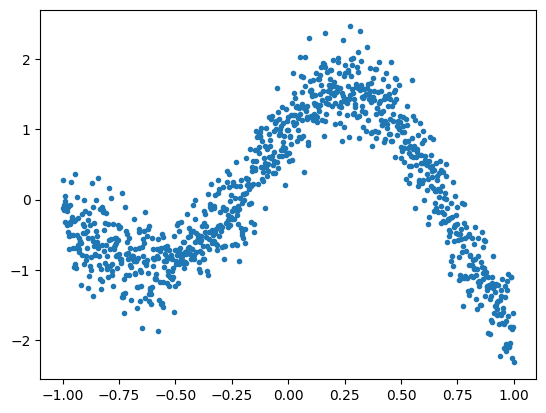

In [2]:
X = np.linspace(-1, 1, 1000)
ruido = np.random.normal(0, 0.333, 1000)
y = np.sin(4*X) + np.cos(3*X) + ruido
plt.plot(X,y, '.')

El modelo más simple que se puede construir es una línea recta de la forma:
$$ y = w_0 + w_{1}*x$$

Donde $w_0$ es el intercepto de la línea y $w_1$ es la pendiente de la línea.

Con un modelo de regresión lineal simple se pueden encontrar los mejores valores de estos parámetros.

In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
X = X.reshape(-1,1)
model.fit(X,y)
model.score(X,y)

0.04219213857830828

In [4]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'La pendiente del modelo es {model.coef_[0]:.3f}')

El intercepto del modelo es 0.048
La pendiente del modelo es 0.364


Si se compara lo que predice el modelo contra los datos reales, evidentemente el modelo es malísimo.

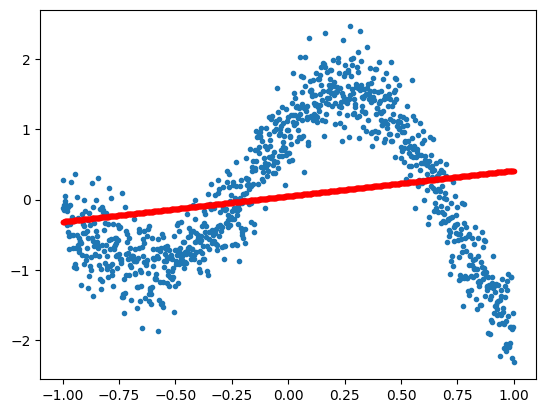

In [5]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X), 'r.')

Para poder **cuantificar** que tan bueno es un modelo es necesario usar una **métrica de evaluación**. El método `score` mide el modelo usando una métrica, que en este caso es el [coeficiente de determinación](https://es.wikipedia.org/wiki/Coeficiente_de_determinaci%C3%B3n) o $R^2$.

In [6]:
print(f'R^2 del modelo: {model.score(X,y):.3f}')

R^2 del modelo: 0.042


# Métricas de evaluación

Este resultado nos corrobora que este modelo es malísimo, porque mientras más cerca a 0 peor, y mientras más cerca a 1, mejor.

Sin embargo, es posible, y deseable, usar otras métricas. Scikit Learn tiene un buen conjunto de métricas implementadas (que puede consultar [aquí](https://scikit-learn.org/stable/modules/model_evaluation.html)).
Métricas de regresión muy utilizadas son el **MSE** ([Mean squared error](https://es.wikipedia.org/wiki/Error_cuadr%C3%A1tico_medio)), **RMSE** (Root mean squared error), el **MAE** ([Mean absolute error](https://es.wikipedia.org/wiki/Error_absoluto_medio)), y el [Median absolute error](https://scikit-learn.org/stable/modules/model_evaluation.html#median-absolute-error).

Es importante notar que las **métricas de evaluación** son funciones que tienen el propósito de evaluar el modelo, mientras que las **funciones de error** son las funciones que intenta optimizar el algoritmo de optimización que encuentra los parámetros del modelo. De esta manera, pueden ser funciones matemáticas diferentes (o las mismas también).

In [7]:
from sklearn.metrics import median_absolute_error, root_mean_squared_error

print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X)):.3f}')
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X)):.3f}')

RMSE del modelo: 1.004
MedAE del modelo: 0.728


# Extracción de características

Se podría intentar obtener un mejor modelo **añadiendo nuevas características** al modelo, en este caso, elevando la variable predictora a alguna potencia. Esto se llama un **modelo de regresión polinómica**.

Vamos a empezar con un modelo polinómico de grado 2, de la forma:
$$ y = w_0 + w_{1}*x + w_{2}*x^2$$

Aunque esto se podría hacer a mano en este caso simple, se va a usar el método `PolynomialFeatures` de Scikit Learn.


In [8]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_p = poly.fit_transform(X)
X_p

array([[-1.        ,  1.        ],
       [-0.997998  ,  0.996     ],
       [-0.995996  ,  0.99200802],
       ...,
       [ 0.995996  ,  0.99200802],
       [ 0.997998  ,  0.996     ],
       [ 1.        ,  1.        ]], shape=(1000, 2))

In [9]:
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X_p)):.3f}')

R^2 del modelo: 0.486
RMSE del modelo: 0.735
MedAE del modelo: 0.582


Evidentemente el modelo mejora, aunque todavía es malo.

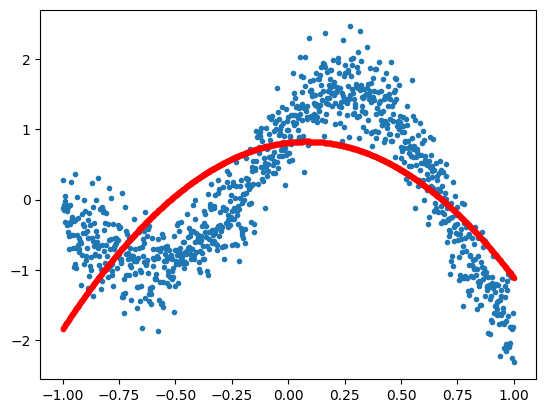

In [10]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.')

Este modelo ya tendría 3 parámetros: el intercepto, la pendiente del término lineal, y la pendiente del término cuadrático.

In [11]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'El coeficiente del término lineal del modelo es {model.coef_[0]:.3f}')
print(f'El coeficiente del término cuadrático del modelo es {model.coef_[1]:.3f}')

El intercepto del modelo es 0.812
El coeficiente del término lineal del modelo es 0.364
El coeficiente del término cuadrático del modelo es -2.287


Ahora, se va a probar con un modelo polinómico de grado 3.

In [12]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_p = poly.fit_transform(X)
X_p

array([[-1.        ,  1.        , -1.        ],
       [-0.997998  ,  0.996     , -0.99400601],
       [-0.995996  ,  0.99200802, -0.98803602],
       ...,
       [ 0.995996  ,  0.99200802,  0.98803602],
       [ 0.997998  ,  0.996     ,  0.99400601],
       [ 1.        ,  1.        ,  1.        ]], shape=(1000, 3))

In [13]:
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
print(f'MedAE del modelo: {median_absolute_error(y, model.predict(X_p)):.3f}')

R^2 del modelo: 0.841
RMSE del modelo: 0.408
MedAE del modelo: 0.267


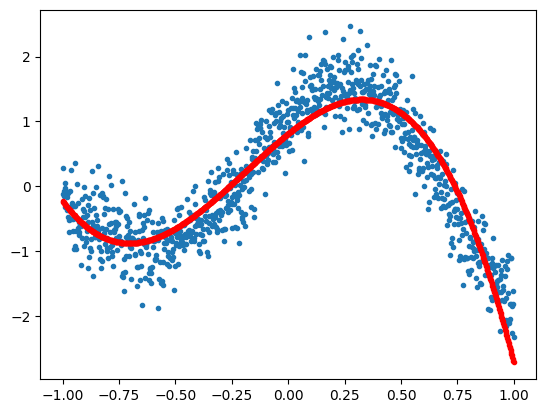

In [14]:
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.')

In [15]:
print(f'El intercepto del modelo es {model.intercept_:.3f}')
print(f'El coeficiente del término lineal del modelo es {model.coef_[0]:.3f}')
print(f'El coeficiente del término cuadrático del modelo es {model.coef_[1]:.3f}')
print(f'El coeficiente del término cúbico del modelo es {model.coef_[2]:.3f}')

El intercepto del modelo es 0.812
El coeficiente del término lineal del modelo es 2.788
El coeficiente del término cuadrático del modelo es -2.287
El coeficiente del término cúbico del modelo es -4.032


Pareciera que mientras más alto sea el grado del modelo, mejor predice. Se va a verificar con grados más altos de polinomios:

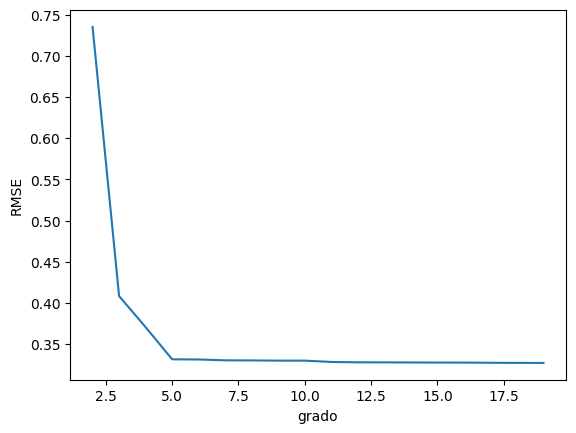

In [16]:
degrees = range(2,20)
scores_rmse = []
for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False)
  X_p = poly.fit_transform(X)
  model.fit(X_p,y)
  scores_rmse.append(root_mean_squared_error(y, model.predict(X_p)))

fig = plt.figure()
plt.plot(degrees, scores_rmse, '-')
plt.xlabel('grado')
plt.ylabel('RMSE');

Se observa que después de cierto grado (5 o 6), el modelo mejora muy poco, así que aumentar la complejidad del modelo no garantiza que funcione mejor.

In [17]:
scores = pd.DataFrame({'grado': degrees, 'RMSE': scores_rmse})
scores.set_index('grado', inplace=True)
scores.sort_values(by='RMSE', ascending=True).head(10)

,RMSE
grado,
19,0.327070
18,0.327106
17,0.327246
16,0.327471
15,0.327514
14,0.327625
13,0.327742
12,0.327805
11,0.328247


En este caso el error se acerca asintóticamente a la desviación estándar del ruido, pero nunca va a ser menor a este.

R^2 del modelo: 0.901
RMSE del modelo: 0.323


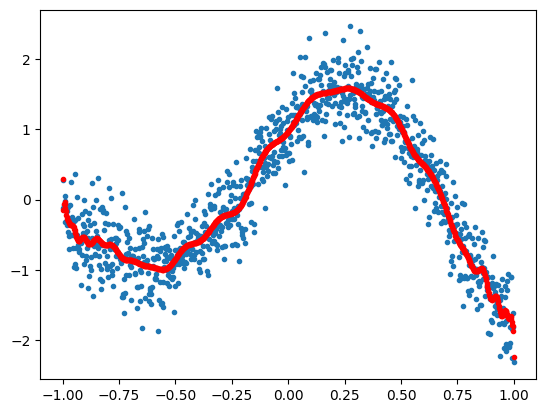

In [18]:
poly = PolynomialFeatures(degree=100, include_bias=False)
X_p = poly.fit_transform(X)
model.fit(X_p,y)
print(f'R^2 del modelo: {model.score(X_p,y):.3f}')
print(f'RMSE del modelo: {root_mean_squared_error(y, model.predict(X_p)):.3f}')
plt.plot(X,y, '.')
plt.plot(X, model.predict(X_p), 'r.')

Por otra parte, los coeficientes se hacen más grandes a medida que aumenta  el grado del polinomio:

In [19]:
model.coef_

array([ 4.10577524e+00,  2.82110071e+01, -8.66102506e+01, -2.51235829e+03,
        6.72184483e+03,  7.33329563e+04, -2.15746757e+05, -1.09219021e+06,
        3.61575896e+06,  9.23712245e+06, -3.67065171e+07, -4.44500556e+07,
        2.42359540e+08,  9.80917890e+07, -1.07232706e+09,  1.14801768e+08,
        3.17015120e+09, -1.39330930e+09, -5.96329170e+09,  3.90067807e+09,
        5.98455723e+09, -4.68719108e+09, -4.33447537e+08,  2.62761557e+08,
       -4.84143359e+09,  4.38322870e+09,  1.13281156e+09, -5.81509090e+08,
        4.33654671e+09, -4.20265067e+09,  3.75511504e+08, -1.10089489e+09,
       -3.68362163e+09,  3.29348990e+09, -2.69565580e+09,  3.31632429e+09,
        1.29214839e+09, -3.78587426e+08,  3.59373191e+09, -3.43912203e+09,
        2.25121206e+09, -3.05584918e+09, -1.01035370e+09, -2.09631704e+07,
       -3.22234293e+09,  2.85200509e+09, -2.79084010e+09,  3.37828056e+09,
       -3.32183229e+08,  1.43591477e+09,  2.23910970e+09, -1.39164374e+09,
        3.22029499e+09, -

In [20]:
model.intercept_

np.float64(0.9705610766319677)